# Sentiment Analysis on Twitter & Reddit Data
**Dataset:** [Twitter and Reddit Sentimental Analysis Dataset](https://www.kaggle.com/datasets/cosmos98/twitter-and-reddit-sentimental-analysis-dataset) (Kaggle) — `Twitter_Data.csv` and `Reddit_Data.csv`, combined into a single corpus.

**Goal:** Build and compare two text classifiers (Naive Bayes and Logistic Regression) that predict whether a social-media post expresses **positive**, **negative**, or **neutral** sentiment.


## 1. Load Dataset & Inspect Class Distribution

Both source files use a `category` column with numeric labels: `1` = positive, `0` = neutral, `-1` = negative. We load each file, standardize the column names, tag each row with its `source` (twitter/reddit), and concatenate them into one dataset.


In [1]:
import pandas as pd
import numpy as np

reddit = pd.read_csv('Reddit_Data.csv').rename(columns={'clean_comment': 'text', 'category': 'label'})
twitter = pd.read_csv('Twitter_Data.csv').rename(columns={'clean_text': 'text', 'category': 'label'})
reddit['source'] = 'reddit'
twitter['source'] = 'twitter'

df = pd.concat([reddit, twitter], ignore_index=True)
print(f"Combined raw shape: {df.shape}")
df.head()


Combined raw shape: (200229, 3)


,text,label,source
0,family mormon have never tried explain them t...,1.0,reddit
1,buddhism has very much lot compatible with chr...,1.0,reddit
2,seriously don say thing first all they won get...,-1.0,reddit
3,what you have learned yours and only yours wha...,0.0,reddit
4,for your own benefit you may want read living ...,1.0,reddit


In [2]:
# Drop missing text/label rows, cast label to int, map to readable sentiment names
df = df.dropna(subset=['text', 'label']).copy()
df['label'] = df['label'].astype(int)

label_map = {1: 'positive', 0: 'neutral', -1: 'negative'}
df['sentiment'] = df['label'].map(label_map)

# Drop duplicate/empty texts
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0]
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Final cleaned shape: {df.shape}")
df[['text', 'sentiment', 'source']].head()


Final cleaned shape: (197357, 4)


,text,sentiment,source
0,family mormon have never tried explain them th...,positive,reddit
1,buddhism has very much lot compatible with chr...,positive,reddit
2,seriously don say thing first all they won get...,negative,reddit
3,what you have learned yours and only yours wha...,neutral,reddit
4,for your own benefit you may want read living ...,positive,reddit


In [3]:
print("Overall class distribution:")
print(df['sentiment'].value_counts())
print()
print("Class distribution (%):")
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)
print()
print("Rows per source:")
print(df['source'].value_counts())
print()
print("Class distribution by source:")
print(pd.crosstab(df['source'], df['sentiment']))


Overall class distribution:
sentiment
positive    87136
neutral     66864
negative    43357
Name: count, dtype: int64

Class distribution (%):
sentiment
positive    44.2
neutral     33.9
negative    22.0
Name: proportion, dtype: float64

Rows per source:
source
twitter    160750
reddit      36607
Name: count, dtype: int64

Class distribution by source:
sentiment  negative  neutral  positive
source                                
reddit         8233    12650     15724
twitter       35124    54214     71412


**Note on class balance:** the positive class is noticeably larger than negative and neutral (roughly a 2:1.6:1 ratio). This is common in real social-media data and is *not* corrected by discarding data — instead we account for it later by using stratified train/test splitting and, for Logistic Regression, `class_weight='balanced'` so the model doesn't just learn to favor the majority class.


## 2. Text Preprocessing Pipeline

Steps applied to every document:
1. Lowercase the text
2. Remove punctuation and digits
3. Tokenize (whitespace split on the cleaned string)
4. Remove stopwords (scikit-learn's built-in English stopword list — this avoids any external NLTK data downloads, keeping the notebook fully self-contained/offline-runnable)
5. Apply stemming (Porter Stemmer from NLTK — the stemmer algorithm itself needs no downloaded corpora, only the `nltk` package)

Note: the source text in this dataset has already had most special characters/URLs/mentions stripped upstream, so our pipeline focuses on normalization rather than heavy scrubbing.


In [4]:
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
STOPWORDS = set(ENGLISH_STOP_WORDS)

def preprocess(text: str) -> str:
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and digits
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    # 3. Tokenize
    tokens = text.split()
    # 4. Remove stopwords (+ stray single characters)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    # 5. Stem
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)
# Drop rows that became empty after cleaning (e.g. text was only stopwords/punctuation)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"Shape after preprocessing: {df.shape}")
df[['text', 'clean_text']].head(10)


Shape after preprocessing: (197183, 5)


,text,clean_text
0,family mormon have never tried explain them th...,famili mormon tri explain stare puzzl time tim...
1,buddhism has very much lot compatible with chr...,buddhism lot compat christian especi consid si...
2,seriously don say thing first all they won get...,serious don say thing won complex explain norm...
3,what you have learned yours and only yours wha...,learn want teach differ focu goal wrap paper b...
4,for your own benefit you may want read living ...,benefit want read live buddha live christ thic...
5,you should all sit down together and watch the...,sit watch simpson episod lisa buddhist simpson...
6,was teens when discovered zen meditation was t...,teen discov zen medit undiagnos bpd homeschool...
7,jesus was zen meets jew,jesu zen meet jew
8,there are two varieties christians dogmatic th...,varieti christian dogmat dwell word conserv he...
9,dont worry about trying explain yourself just ...,dont worri tri explain just medit regularli tr...


## 3. Feature Extraction: TF-IDF Vectorizer

**Why TF-IDF?** Term Frequency–Inverse Document Frequency converts text into numerical vectors that machine learning models can consume. It weighs each word by:

- **Term Frequency (TF):** how often a word appears in a given document (higher = more important to that document).
- **Inverse Document Frequency (IDF):** how rare that word is *across the whole corpus* (words that appear in almost every post get down-weighted; distinctive words get up-weighted).

The product, TF-IDF, highlights words that are frequent in a specific document but not common across all documents — which is far more informative for classification than raw word counts (Bag-of-Words), since it automatically suppresses generic, low-signal terms. We cap the vocabulary at `max_features` and include bigrams so short phrases (e.g. "not good") are captured alongside single words.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=5, max_df=0.9)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print(f"TF-IDF feature matrix shape: {X.shape}")


TF-IDF feature matrix shape: (197183, 8000)


## 4. Train/Test Split (80/20, Stratified)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 157746  |  Test size: 39437


## 5. Train Classifiers

We train two models:
1. **Multinomial Naive Bayes** — a fast, strong baseline for text classification that assumes word-count-like features are conditionally independent given the class.
2. **Logistic Regression** (`class_weight='balanced'`) — a linear discriminative model that often outperforms Naive Bayes on TF-IDF features because it directly optimizes the decision boundary; the balanced class weights compensate for the positive-class majority noted in Section 1.


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
lr_model.fit(X_train, y_train)

print("Both models trained.")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Both models trained.


## 6. Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print()
    print(classification_report(y_test, preds, zero_division=0))
    return preds, {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

nb_preds, nb_metrics = evaluate("Multinomial Naive Bayes", nb_model, X_test, y_test)
lr_preds, lr_metrics = evaluate("Logistic Regression", lr_model, X_test, y_test)


=== Multinomial Naive Bayes ===
Accuracy:  0.6762
Precision: 0.6967
Recall:    0.6762
F1-score:  0.6653



              precision    recall  f1-score   support

    negative       0.79      0.42      0.55      8670
     neutral       0.72      0.61      0.66     13341
    positive       0.63      0.85      0.73     17426

    accuracy                           0.68     39437
   macro avg       0.71      0.63      0.65     39437
weighted avg       0.70      0.68      0.67     39437



=== Logistic Regression ===
Accuracy:  0.8111
Precision: 0.8198
Recall:    0.8111
F1-score:  0.8114



              precision    recall  f1-score   support

    negative       0.73      0.78      0.75      8670
     neutral       0.78      0.90      0.83     13341
    positive       0.90      0.76      0.82     17426

    accuracy                           0.81     39437
   macro avg       0.80      0.81      0.80     39437
weighted avg       0.82      0.81      0.81     39437



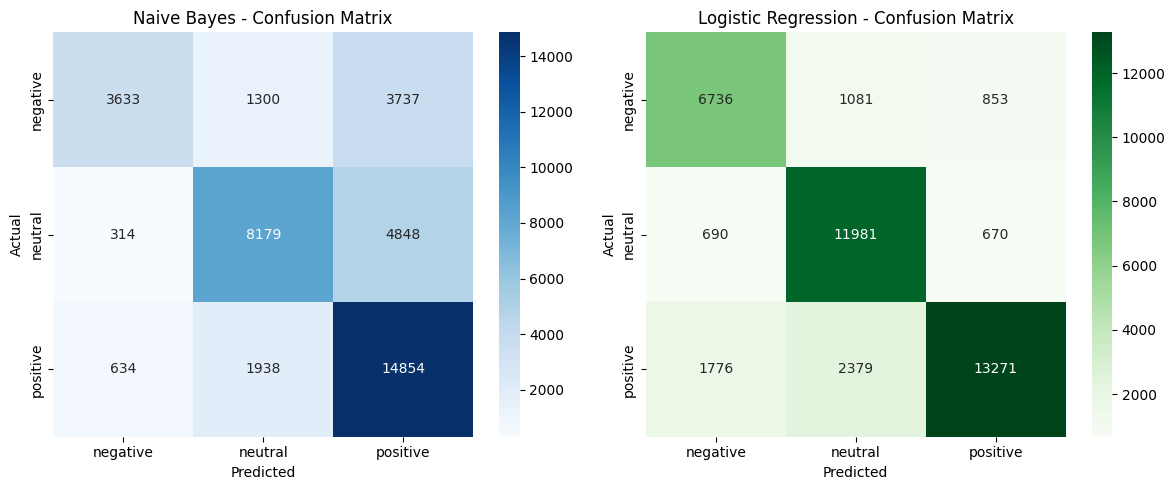

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y.unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_preds, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()


In [10]:
# Side-by-side metric comparison
comparison = pd.DataFrame({
    'Naive Bayes': nb_metrics,
    'Logistic Regression': lr_metrics
}).T
comparison


,accuracy,precision,recall,f1
Naive Bayes,0.676167,0.696719,0.676167,0.665289
Logistic Regression,0.811116,0.819793,0.811116,0.811355


## 7. Visualizations

### 7.1 Sentiment Distribution

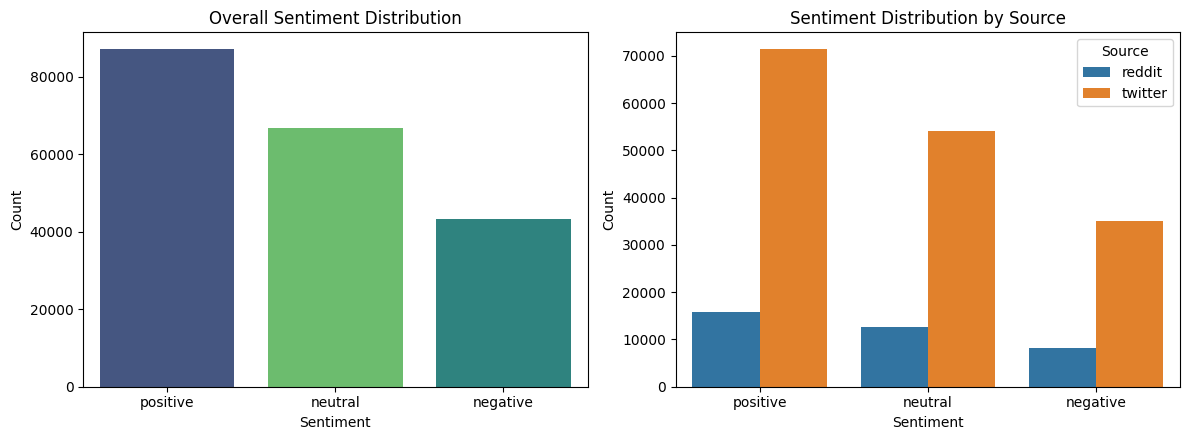

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = df['sentiment'].value_counts().index
sns.countplot(data=df, x='sentiment', order=order, hue='sentiment', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('Overall Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='sentiment', hue='source', order=order, ax=axes[1])
axes[1].set_title('Sentiment Distribution by Source')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].legend(title='Source')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=120)
plt.show()


### 7.2 Word Clouds per Sentiment Class

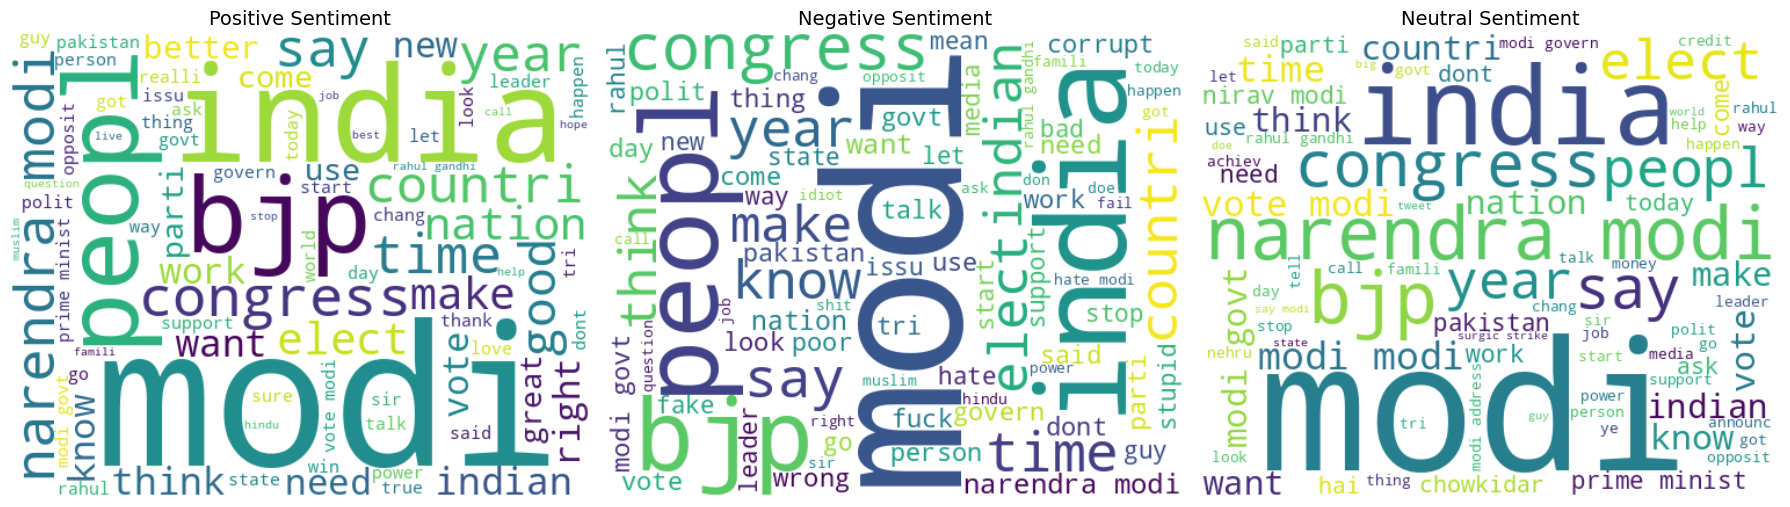

In [12]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    # Sample to keep word cloud generation fast on this large corpus
    subset = df.loc[df['sentiment'] == sentiment, 'clean_text']
    subset = subset.sample(min(20000, len(subset)), random_state=1)
    text_blob = " ".join(subset)
    wc = WordCloud(width=500, height=400, background_color='white',
                    colormap='viridis', max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Sentiment', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=120)
plt.show()


## 8. Error Analysis

We inspect a handful of misclassified examples from the better-performing model to understand *why* the model gets them wrong.


In [13]:
best_name = 'Logistic Regression' if lr_metrics['f1'] >= nb_metrics['f1'] else 'Naive Bayes'
best_preds = lr_preds if best_name == 'Logistic Regression' else nb_preds

test_idx = y_test.index
results_df = pd.DataFrame({
    'text': df.loc[test_idx, 'text'].values,
    'clean_text': df.loc[test_idx, 'clean_text'].values,
    'source': df.loc[test_idx, 'source'].values,
    'actual': y_test.values,
    'predicted': best_preds
})

misclassified = results_df[results_df['actual'] != results_df['predicted']]
print(f"Best model: {best_name}")
print(f"Misclassified: {len(misclassified)} / {len(results_df)} test examples ({len(misclassified)/len(results_df)*100:.1f}%)")
print()

sample = misclassified.sample(min(5, len(misclassified)), random_state=3)
for i, row in sample.reset_index(drop=True).iterrows():
    print(f"Example {i+1}  (source: {row['source']})")
    print(f"  Text:      {row['text'][:200]}")
    print(f"  Actual:    {row['actual']}")
    print(f"  Predicted: {row['predicted']}")
    print()


Best model: Logistic Regression
Misclassified: 7449 / 39437 test examples (18.9%)

Example 1  (source: twitter)
  Text:      one night modi applied poison his sole mistake next morning many presstitutes were dead
  Actual:    positive
  Predicted: negative

Example 2  (source: twitter)
  Text:      rajdeep the bootlicker 10jp italian amma got slapped modi
saurav ganguli sania mirza raj thackeray smriti irani
mukesh ambani and none other than former president india pranav mukherjee pls add more y
  Actual:    positive
  Predicted: neutral

Example 3  (source: twitter)
  Text:      spoke leader the nation not leader particular party this opposition leaders who are barking him unnecessarily doing this they are only campaigning for modi and nothing else salute our scientists❤️❤️❤️
  Actual:    negative
  Predicted: positive

Example 4  (source: twitter)
  Text:      whats the difference between and modi bhakts both are the same putting there opinion others with out understanding the other 

**Likely reasons for misclassification, based on the patterns above:**

1. **Neutral vs. positive/negative overlap** — neutral posts often mention the same topics and even similar words as opinionated posts, just without a clear sentiment-bearing verdict; this is consistently the hardest boundary for a bag-of-words model, since TF-IDF has no notion of degree or stance strength.
2. **Sarcasm and rhetorical questions** — social-media text (especially political commentary, which makes up a large share of the Twitter subset) frequently uses sarcasm, rhetorical questions, or irony that read as one sentiment lexically but mean the opposite in context — something a linear bag-of-words model cannot detect.
3. **Mixed sentiment within one post** — a single post can praise one aspect and criticize another; TF-IDF sums word-level signal across the whole document, so mixed posts often get pulled toward whichever sentiment has more/stronger vocabulary rather than reflecting genuine ambiguity.
4. **Noisy/crowd-sourced labels** — datasets like this are typically labeled by different annotators (or heuristics) at scale, so some genuine label noise or borderline judgment calls are expected, and a portion of "misclassifications" may actually be defensible alternative readings of an ambiguous post.
5. **Short or informal text** — very short comments, or ones dominated by slang/abbreviations not well represented in the TF-IDF vocabulary, leave little reliable signal for the model to work with.

In production, addressing these would likely involve richer features (negation handling, sarcasm-aware or sentiment-lexicon features) or contextual embeddings from a transformer model, rather than only bag-of-words/TF-IDF.


## 9. Conclusion & Real-World Applications


In [14]:
print(f"Naive Bayes          -> F1: {nb_metrics['f1']:.4f}, Accuracy: {nb_metrics['accuracy']:.4f}")
print(f"Logistic Regression   -> F1: {lr_metrics['f1']:.4f}, Accuracy: {lr_metrics['accuracy']:.4f}")
print()
print(f"Best performing model: {best_name}")


Naive Bayes          -> F1: 0.6653, Accuracy: 0.6762
Logistic Regression   -> F1: 0.8114, Accuracy: 0.8111

Best performing model: Logistic Regression


### Summary

Both models were trained on TF-IDF features (unigrams + bigrams) extracted from cleaned, stemmed Twitter and Reddit text, and evaluated on a held-out, stratified 20% test split. The metric comparison table and confusion matrices above show how each model handles the three-way positive/negative/neutral classification, with most confusion concentrated at the neutral boundary and on posts with mixed or sarcastic sentiment — consistent with the error analysis in Section 8.

### Real-World Applications

- **Social listening / brand monitoring:** track sentiment trends over time across Twitter and Reddit for a product, campaign, or public figure to gauge real-time public reception.
- **Customer feedback triage:** automatically flag strongly negative posts or comments for a support or PR team to address first.
- **Public opinion / policy research:** aggregate sentiment on a topic across platforms to compare how different communities (e.g. Twitter vs. Reddit) discuss the same subject.
- **Content moderation support:** combine sentiment signals with other features to help prioritize review of hostile or highly negative content.
- **Market/competitive research:** compare sentiment volume and polarity across competing products, brands, or campaigns scraped from social platforms.

### Next Steps
- Try contextual embeddings (e.g. a fine-tuned transformer) to better capture negation, sarcasm, and mixed sentiment.
- Investigate per-source models (Twitter vs. Reddit) since writing style and length differ meaningfully between the two platforms.
- Audit a sample of the "neutral" class specifically, since it is the most confused class and may benefit from clearer labeling guidelines or a finer-grained rating scale.
